1. Data Exploration

In this step I need to explore the data provided in the two provided csv's. we know that there are two csv files but the exact relation between the data in each file is not still clear since the provider did not mention the relation clear enough. Also It is better to understand the type of each column and the distribution of values in each columns which can help us understand the data better. So, in this file I am going to implement some basic exploration regarding the explaination I mentioned.

In [7]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if not (ROOT / 'data').exists():
    raise RuntimeError('Run from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
RAW = ROOT/'data/raw'; OUT = ROOT/'figures/eda'; REPORT = ROOT/'results/reports'
OUT.mkdir(parents=True, exist_ok=True); REPORT.mkdir(parents=True, exist_ok=True)
forms = pd.read_csv(RAW/'Construction_Data_PM_Forms_All_Projects.csv', low_memory=False)
tasks = pd.read_csv(RAW/'Construction_Data_PM_Tasks_All_Projects.csv', low_memory=False)
print({'forms_shape': forms.shape, 'tasks_shape': tasks.shape})


{'forms_shape': (10254, 17), 'tasks_shape': (12424, 19)}


2. Column-level profile

In [8]:
def get_profile(df):
    return pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                          'missing_pct': (df.isna().mean()*100).round(2), 'unique': df.nunique(dropna=False)})
forms_profile = get_profile(forms)
tasks_profile = get_profile(tasks)

forms_profile.to_csv(REPORT/'forms_profile.csv'); 
tasks_profile.to_csv(REPORT/'tasks_profile.csv')

print('Duplicates:', {'forms': int(forms.duplicated().sum()), 'tasks': int(tasks.duplicated().sum())})
forms_profile


Duplicates: {'forms': 0, 'tasks': 0}


,dtype,missing,missing_pct,unique
Ref,object,0,0.00,9858
Status,object,0,0.00,26
Location,object,0,0.00,814
Name,object,0,0.00,125
Created,object,0,0.00,433
Type,object,0,0.00,13
Status Changed,object,0,0.00,349
Open Actions,int64,0,0.00,14
Total Actions,int64,0,0.00,32
Association,object,8156,79.54,3


In [9]:
tasks_profile

,dtype,missing,missing_pct,unique
Ref,object,0,0.00,12118
Status,object,0,0.00,16
Location,object,0,0.00,594
Description,object,0,0.00,10268
Created,object,0,0.00,351
Target,float64,9856,79.33,256
Type,object,0,0.00,37
To Package,object,1042,8.39,106
Status Changed,object,0,0.00,361
Association,object,2941,23.67,4


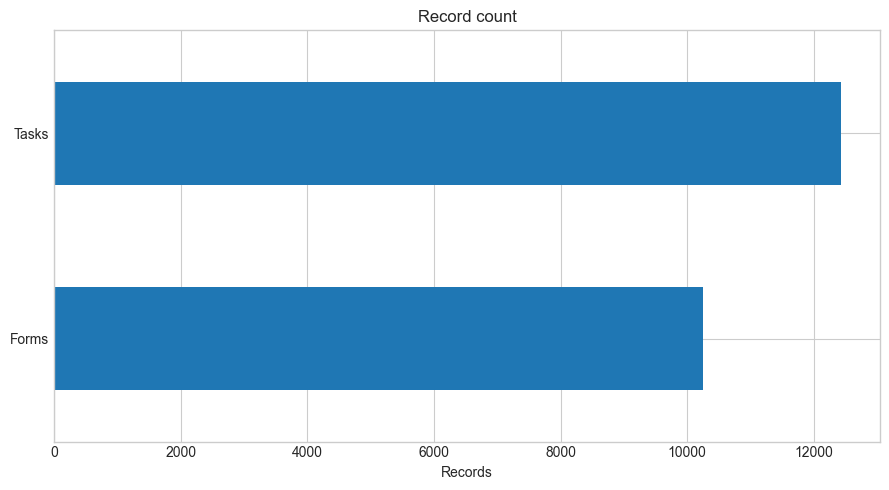

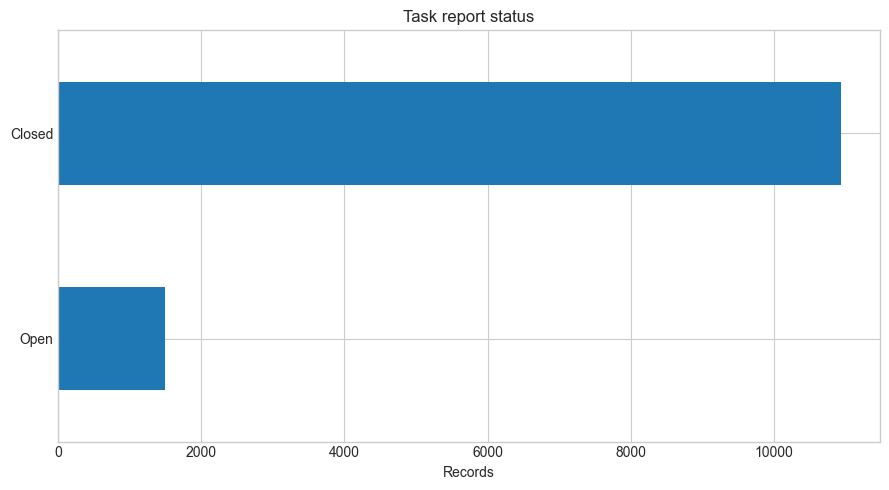

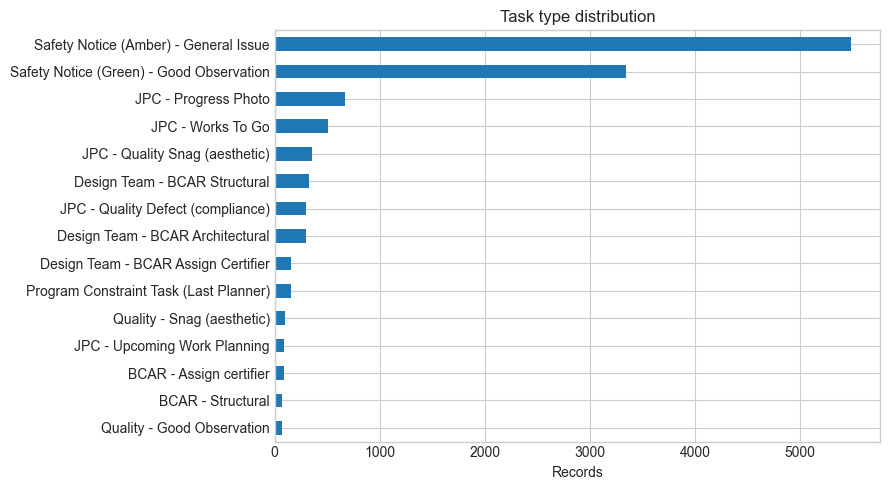

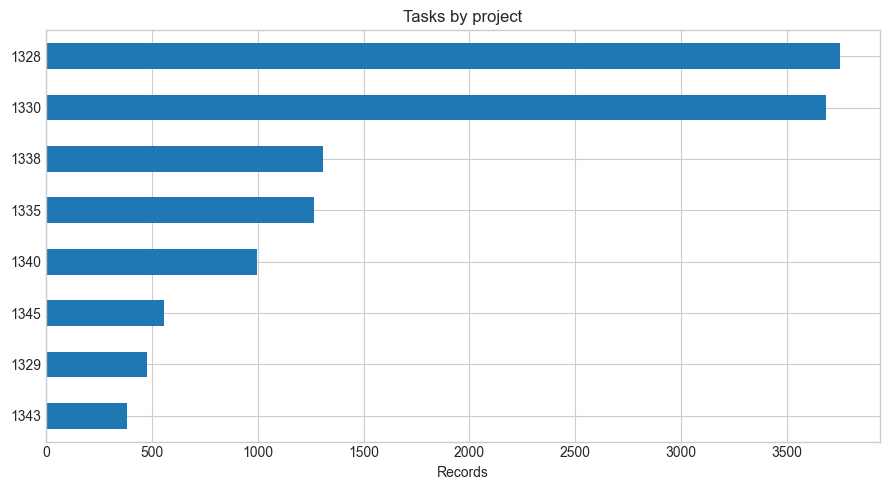

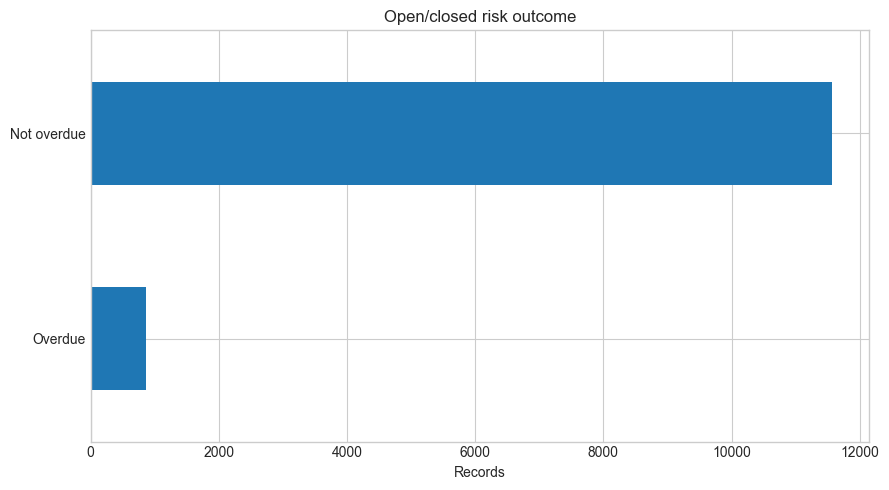

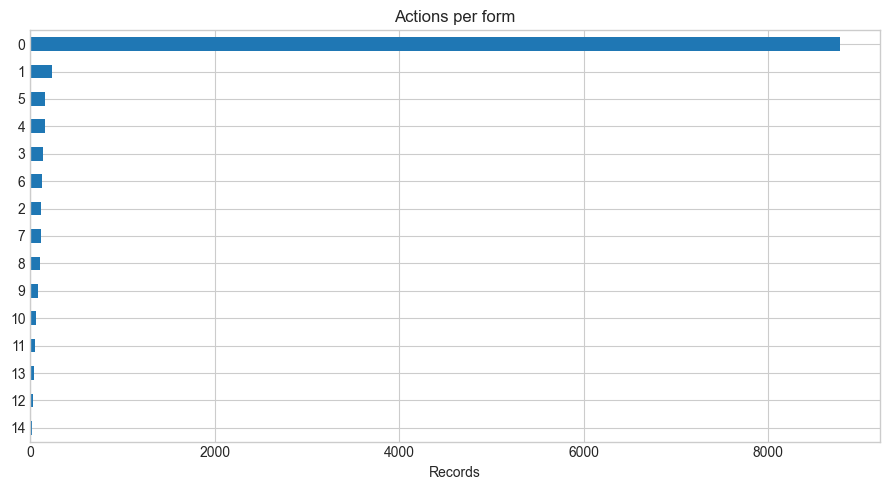

In [10]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def create_bar(series, title, filename, n=15, auto_count=True):
    counts = series.value_counts(dropna=False) if auto_count else series
    ax = counts.head(n).sort_values().plot.barh(figsize=(9, 5), color='#1f77b4')
    ax.set(title=title, xlabel='Records', ylabel='')
    plt.tight_layout()
    plt.savefig(OUT/filename, dpi=160)
    plt.show()


create_bar(pd.Series({'Forms': len(forms), 'Tasks': len(tasks)}), 'Record count', 'record_counts.png', auto_count=False)
create_bar(tasks['Report Status'], 'Task report status', 'task_status_distribution.png')
create_bar(tasks['Type'], 'Task type distribution', 'task_type_distribution.png')
create_bar(tasks['project'], 'Tasks by project', 'task_project_distribution.png')
create_bar(tasks['OverDue'].map({True: 'Overdue', False: 'Not overdue'}), 'Open/closed risk outcome', 'overdue_distribution.png')
create_bar(forms['Total Actions'], 'Actions per form', 'form_actions_distribution.png')


In [11]:
projects_match = set(forms['Project']) == set(tasks['project'])
relationship = {'shared_projects': sorted(set(forms['Project']) & set(tasks['project'])), 'project_sets_match': projects_match, 'direct_ref_join_available': False, 'note': 'Association contains workflow labels (for example FormAnswer), not form references.'}
pd.Series(relationship, dtype='object').to_json(REPORT/'dataset_relationship.json', indent=2)
with open(REPORT/'eda_summary.md', 'w', encoding='utf-8') as f:
    f.write(f"# EDA summary\n\nForms: {len(forms):,}; tasks: {len(tasks):,}.\n\nTasks overdue: {tasks['OverDue'].sum():,} ({tasks['OverDue'].mean():.1%}).\n\nTables are related reliably at the project level; no direct record-level key was found.\n")
relationship

{'shared_projects': [1328, 1329, 1330, 1335, 1338, 1340, 1343, 1345],
 'project_sets_match': True,
 'direct_ref_join_available': False,
 'note': 'Association contains workflow labels (for example FormAnswer), not form references.'}